<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/11_Numerical-to-Categoriacl_Encoding/11_Numerical_to_Categorical_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Encoding Numerical Features

## --> two types
a. Discretization (binning)

b. Binarization

Discretization is the process of the transforming contnuous variables into discrete variables by  creating a set of contiguous intervals that span the range of the variable's values. Discretization is also called binning, where bin is an alternative name for interval.

Why use Discretization:

1. To handle Outliers

2. To improve the value spread


# a. Types of Discretization

1. Unsupervised binning

   a. equal width (Uniform)

   b. equal frequency (quantile)

   c. Kmeans binning

2. Supervised binning

   a. DecisionTree binning
   
3. Custom binning


# a . Equal Width/ Uniform binning

In [ ]:
# bins you choose
# formula = (max - min)/bins

# b. Equal Frequency/ Quantile Binning

In [ ]:
# intervals = 10
# Each interval contains 10% of total observations...

# good works on the outliers
# valuespread uniform ko banta hai



# c. Kmean binning


In [ ]:
# kmean algorithms to form cluster
# it used when the data in the form of clusters...

# Encoding the discretized variable

In [ ]:
# sklearn -> KBinsDiscretized(bins = , strategy = (uniform or quantile or kmean), encoding)

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [28]:
df1 = sns.load_dataset("titanic")

In [29]:
df = df1.iloc[:,[0,3,6]]
df

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [64]:
df['age'].fillna(df['age'].mean(), inplace=True)

/tmp/ipykernel_709/1503503937.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_709/1503503937.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'].fillna(df['age'].mean(), inplace=True)


In [66]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [67]:
X_train.shape, X_test.shape

((712, 2), (179, 2))

In [68]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.6703910614525139

In [70]:
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

np.float64(0.6610611735330837)

In [92]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')

In [93]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [94]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

trf.named_transformers_['first'].n_bins_  # no. of bins  created

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


array([12])

In [95]:
trf.named_transformers_['second'].bin_edges_  # interval check

array([array([  0.     ,   7.2292 ,   7.75   ,   7.88916,   7.925  ,   8.6625 ,
               10.5    ,  13.     ,  15.54834,  21.045  ,  26.     ,  29.355  ,
               39.6875 ,  65.     ,  90.     , 512.3292 ])                     ],
      dtype=object)

In [96]:
output = pd.DataFrame({'age':X_train['age'],
                       'age_trf':X_train_trf[:,0],
                       'fare':X_train['fare'],
                       'fare_trf':X_train_trf[:,1]
                       })

In [97]:
output['age_labels'] = pd.cut(x=X_train['age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(x=X_train['fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [98]:
output

,age,age_trf,fare,fare_trf,age_labels,fare_labels
331,45.5,10.0,28.5000,10.0,"(44.0, 51.0]","(26.0, 29.355]"
733,23.0,4.0,13.0000,7.0,"(21.0, 23.0]","(10.5, 13.0]"
382,32.0,7.0,7.9250,4.0,"(31.0, 34.0]","(7.889, 7.925]"
704,26.0,5.0,7.8542,2.0,"(25.0, 28.0]","(7.75, 7.889]"
813,6.0,0.0,31.2750,11.0,"(0.42, 8.4]","(29.355, 39.688]"
...,...,...,...,...,...,...
106,21.0,3.0,7.6500,1.0,"(18.0, 21.0]","(7.229, 7.75]"
270,28.0,6.0,31.0000,11.0,"(25.0, 28.0]","(29.355, 39.688]"
860,41.0,9.0,14.1083,7.0,"(38.0, 44.0]","(13.0, 15.548]"
435,14.0,1.0,120.0000,14.0,"(8.4, 18.0]","(90.0, 512.329]"


In [102]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)

y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test, y_pred2)

0.6368715083798883

In [101]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y, cv=10, scoring='accuracy'))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


np.float64(0.6453807740324595)

In [115]:
def discretize(bins, strategy):
  kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
  kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

  trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
   ])

  X_trf = trf.fit_transform(x)
  print(np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, y, cv=10, scoring='accuracy')))

  plt.figure(figsize=(14,4))
  plt.subplot(1,2,1)
  sns.histplot(x['age'])
  plt.title("before")

  plt.subplot(1,2,2)
  sns.histplot(X_trf[:,0], color='red')
  plt.title('after')

  plt.show()

  plt.figure(figsize=(14,4))
  plt.subplot(1,2,1)
  sns.histplot(x['fare'])
  plt.title("before")

  plt.subplot(1,2,2)
  sns.histplot(X_trf[:,1], color='red')
  plt.title('after')

  plt.show()


0.6825218476903872


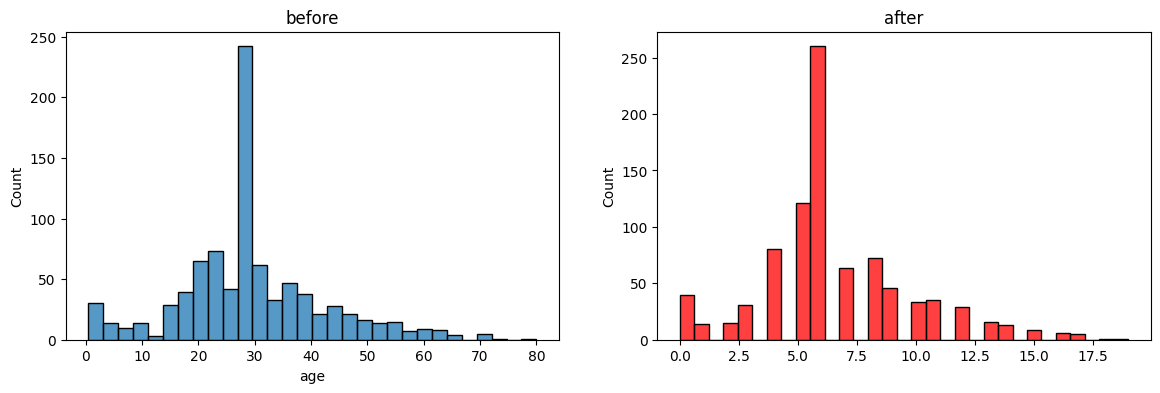

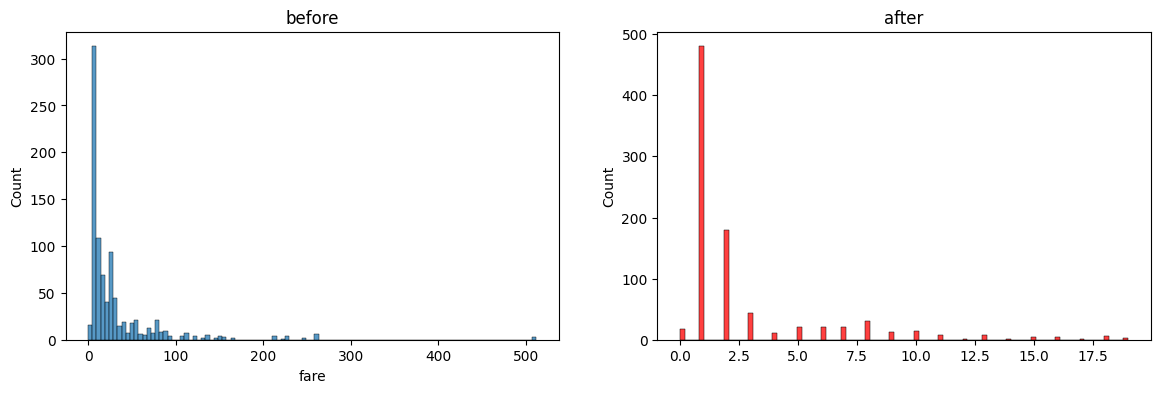

In [118]:
discretize(20, 'kmeans')

# Custom/Domain Based Binning


# 3. Binarization

In [122]:
var = df1.iloc[:,[0,3,4,5,6]]

In [123]:
var

,survived,age,sibsp,parch,fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500
...,...,...,...,...,...
886,0,27.0,0,0,13.0000
887,1,19.0,0,0,30.0000
888,0,NaN,1,2,23.4500
889,1,26.0,0,0,30.0000


In [125]:
var['family'] = var['sibsp'] + var['parch']
var

/tmp/ipykernel_709/2535811461.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var['family'] = var['sibsp'] + var['parch']


,survived,age,sibsp,parch,fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0
...,...,...,...,...,...,...
886,0,27.0,0,0,13.0000,0
887,1,19.0,0,0,30.0000,0
888,0,NaN,1,2,23.4500,3
889,1,26.0,0,0,30.0000,0


In [127]:
var1 = var.drop(columns=['sibsp', 'parch'])
var1

,survived,age,fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0
...,...,...,...,...
886,0,27.0,13.0000,0
887,1,19.0,30.0000,0
888,0,NaN,23.4500,3
889,1,26.0,30.0000,0


In [128]:
x = var1.drop('survived', axis=1)
y = var1.iloc[:,0]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

X_train.head()

,age,fare,family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [130]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.659217877094972

In [132]:
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

np.float64(0.6509612983770288)

In [133]:
# applying Binarization

from sklearn.preprocessing import Binarizer

In [138]:
trf5 = ColumnTransformer([
    ('bin', Binarizer(copy=False), ['family'])
], remainder = 'passthrough')

In [139]:
X_train_trf = trf5.fit_transform(X_train)

X_test_trf = trf5.transform(X_test)

In [140]:
pd.DataFrame(X_train_trf, columns=['family', 'age', 'fare'])

,family,age,fare
0,0.0,45.5,28.5000
1,0.0,23.0,13.0000
2,0.0,32.0,7.9250
3,1.0,26.0,7.8542
4,1.0,6.0,31.2750
...,...,...,...
707,0.0,21.0,7.6500
708,0.0,NaN,31.0000
709,1.0,41.0,14.1083
710,1.0,14.0,120.0000


In [144]:
clf = DecisionTreeClassifier()

clf.fit(X_train_trf, y_train)

y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test, y_pred2)

0.6424581005586593

In [145]:
X_trf5 = trf5.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(), X_trf5, y, cv=10, scoring='accuracy'))

np.float64(0.6509737827715355)